# Variational autoencoders

This notebook walks you through implementing a variational autoencoder (VAE) for the MNIST dataset with a normalizing flow as prior.

In [ ]:
import torch
import torch.nn as nn
import torch.utils.data as data

from torch import Tensor
from torch.distributions import Bernoulli, Distribution, Independent, Normal
from torchvision.datasets import MNIST
from torchvision.transforms.functional import to_pil_image, to_tensor
from tqdm import tqdm
import ivon
import matplotlib.pyplot as plt
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

import zuko

_ = torch.random.manual_seed(0)

## Data

The [MNIST](https://wikipedia.org/wiki/MNIST_database) dataset consists of 28 x 28 grayscale images representing handwritten digits (0 to 9).

In [2]:
trainset = MNIST(root="", download=True, train=True, transform=to_tensor)
trainloader = data.DataLoader(trainset, batch_size=256, shuffle=True)

In [3]:
x = [trainset[i][0] for i in range(16)]
x = torch.cat(x, dim=-1)

to_pil_image(x)

## Evidence lower bound

As usual with variational inference, we wish to find the parameters $\phi$ for which a model $p_\phi(x)$ is most similar to a target distribution $p(x)$, which leads to the objective

$$ \arg \max_\phi \mathbb{E}_{p(x)} \big[ \log p_\phi(x) \big] $$

However, variational autoencoders have latent random variables $z$ and model the joint distribution of $z$ and $x$ as a factorization

$$ p_\phi(x, z) = p_\phi(x | z) \, p_\phi(z) $$

where $p_\phi(x | z)$ is the decoder (sometimes called likelihood) and $p_\phi(z)$ the prior. In this case, maximizing the log-evidence $\log p_\phi(x)$ becomes an issue as the integral

$$ p_\phi(x) = \int p_\phi(z, x) \, \mathrm{d}z $$

is often intractable, not to mention its gradients. To solve this issue, VAEs introduce an encoder $q_\psi(z | x)$ (sometimes called proposal or guide) to define a lower bound for the evidence (ELBO) for which unbiased Monte Carlo estimates of the gradients are available.

$$
\begin{align}
    \log p_\phi(x) & \geq \log p_\phi(x) - \mathrm{KL} \big( q_\psi(z | x) \, || \, p_\phi(z | x) \big) \\
    & \geq \log p_\phi(x) + \mathbb{E}_{q_\psi(z | x)} \left[ \log \frac{p_\phi(z | x)}{q_\psi(z | x)} \right] \\
    & \geq \mathbb{E}_{q_\psi(z | x)} \left[ \log \frac{p_\phi(z, x)}{q_\psi(z | x)} \right] = \mathrm{ELBO}(x, \phi, \psi)
\end{align}
$$

Importantly, if $p_\phi(x, z)$ and $q_\psi(z | x)$ are expressive enough, the bound can become tight and maximizing the ELBO for $\phi$ and $\psi$ will lead to the same model as maximizing the log-evidence.

In [4]:
class ELBO(nn.Module):
    def __init__(
        self,
        encoder: zuko.lazy.LazyDistribution,
        decoder: zuko.lazy.LazyDistribution,
        prior: zuko.lazy.LazyDistribution,
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.prior = prior

    def forward(self, x: Tensor) -> Tensor:
        q = self.encoder(x)
        z = q.rsample()

        return self.decoder(z).log_prob(x) + self.prior().log_prob(z) - q.log_prob(z)

## Model

We choose a (diagonal) Gaussian model as encoder, a Bernoulli model as decoder, and a [Masked Autoregressive Flow](https://arxiv.org/abs/1705.07057) (MAF) as prior. We use 16 features for the latent space.

In [5]:
class GaussianModel(zuko.lazy.LazyDistribution):
    def __init__(self, features: int, context: int):
        super().__init__()

        self.hyper = nn.Sequential(
            nn.Linear(context, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2 * features),
        )

    def forward(self, c: Tensor) -> Distribution:
        phi = self.hyper(c)
        mu, log_sigma = phi.chunk(2, dim=-1)

        return Independent(Normal(mu, log_sigma.exp()), 1)


class BernoulliModel(zuko.lazy.LazyDistribution):
    def __init__(self, features: int, context: int):
        super().__init__()

        self.hyper = nn.Sequential(
            nn.Linear(context, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, features),
        )

    def forward(self, c: Tensor) -> Distribution:
        phi = self.hyper(c)
        rho = torch.sigmoid(phi)

        return Independent(Bernoulli(rho), 1)

In [11]:
encoder = GaussianModel(16, 784)
decoder = BernoulliModel(784, 16)

prior = zuko.flows.MAF(
    features=16,
    transforms=3,
    hidden_features=(256, 256),
)

Note that because the decoder is a Bernoulli model, the data $x$ should be binary.

## Training

As explained earlier, our objective is to maximize the ELBO for all $x$.

$$
\arg \max_{\phi, \, \psi} \mathbb{E}_{p(x)} \big[ \text{ELBO}(x, \phi, \psi) \big]
$$

In [12]:
elbo = ELBO(encoder, decoder, prior).cuda()
optimizer = torch.optim.Adam(elbo.parameters(), lr=1e-3)

for epoch in (bar := tqdm(range(64))):
    losses = []

    for x, _ in trainloader:
        x = x.round().flatten(-3).cuda()

        loss = -elbo(x).mean()
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.detach())

    losses = torch.stack(losses)

    bar.set_postfix(loss=losses.mean().item())

100%|██████████| 64/64 [04:35<00:00,  4.31s/it, loss=65.4]


After training, we can generate MNIST images by sampling latent variables from the prior and decoding them.

In [9]:
z = prior().sample((16,))
x = decoder(z).mean.reshape(-1, 28, 28)

to_pil_image(x.movedim(0, 1).reshape(28, -1))

/tmp/ipykernel_16632/2129190472.py:16: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(
100%|██████████| 64/64 [08:13<00:00,  7.71s/it, loss=58.6]


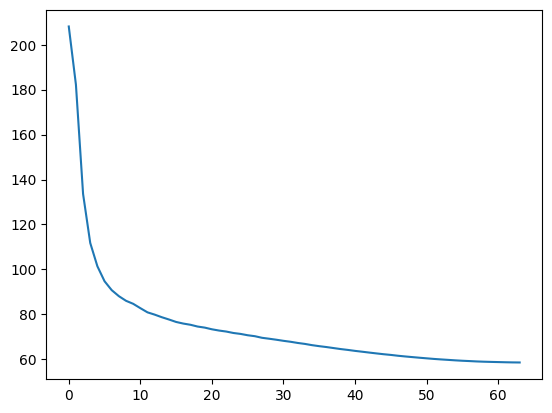

In [9]:
encoder = GaussianModel(16, 784)
decoder = BernoulliModel(784, 16)
prior = zuko.flows.MAF(
    features=16,
    transforms=3,
    hidden_features=(256, 256),
)

train_samples = 4
datasize = len(trainset)
nepoch = 64
nsteps = nepoch * datasize // 256

elbo = ELBO(encoder, decoder, prior).cuda()
optimizer = ivon.IVON(elbo.parameters(), lr=0.1, ess=datasize)
scheduler = LinearWarmupCosineAnnealingLR(
    optimizer,
    warmup_epochs = 10,
    max_epochs = nepoch,
    warmup_start_lr = 0.01,
    eta_min = 0.001
)


mean_losses = []
for epoch in (bar := tqdm(range(64))):
    losses = []

    for x, _ in trainloader:
        x = x.round().flatten(-3).cuda()
        for _ in range(train_samples):
            with optimizer.sampled_params(train=True):
                optimizer.zero_grad()
                loss = -elbo(x).mean()
                loss.backward()

        optimizer.step()          

        losses.append(loss.detach())

    scheduler.step()

    losses = torch.stack(losses)
    
    mean_losses.append(losses.mean().item())
    bar.set_postfix(loss=mean_losses[-1])

plt.plot(mean_losses)


In [10]:
z = prior().sample((16,))
x = decoder(z).mean.reshape(-1, 28, 28)

to_pil_image(x.movedim(0, 1).reshape(28, -1))